# **Drive Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Libraries Import**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #heatmap
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Load the Dataset Path and Validation Data for the CNN**

In [ ]:
dataset_path = '/content/drive/MyDrive/ChiliDoc_Dataset'
img_size = 224
batch_size = 32

exclude_folders = ['chilidoc_vit_model']  # model folders exclude

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_labels = list(val_data.class_indices.keys())
print("Classes:", class_labels)

Found 320 images belonging to 6 classes.
Classes: ['Bacterial_Spot', 'Cercospora_Leaf_Spot', 'Curl_Virus', 'Healthy_Leaf', 'Nutrition_Deficiency', 'White_Spot']


# **CNN Model Load**

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model('/content/drive/MyDrive/ChiliDoc_Models/chilidoc_cnn_model.h5')

# **CNN Predictions + Confusion Matrix**

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 353ms/step
=== CNN Classification Report ===
                      precision    recall  f1-score   support

      Bacterial_Spot       0.92      0.35      0.51        31
Cercospora_Leaf_Spot       0.74      0.81      0.77        36
          Curl_Virus       0.59      0.99      0.74        84
        Healthy_Leaf       0.74      0.63      0.68        91
Nutrition_Deficiency       0.68      0.44      0.53        39
          White_Spot       1.00      0.67      0.80        39

            accuracy                           0.70       320
           macro avg       0.78      0.65      0.67       320
        weighted avg       0.74      0.70      0.69       320



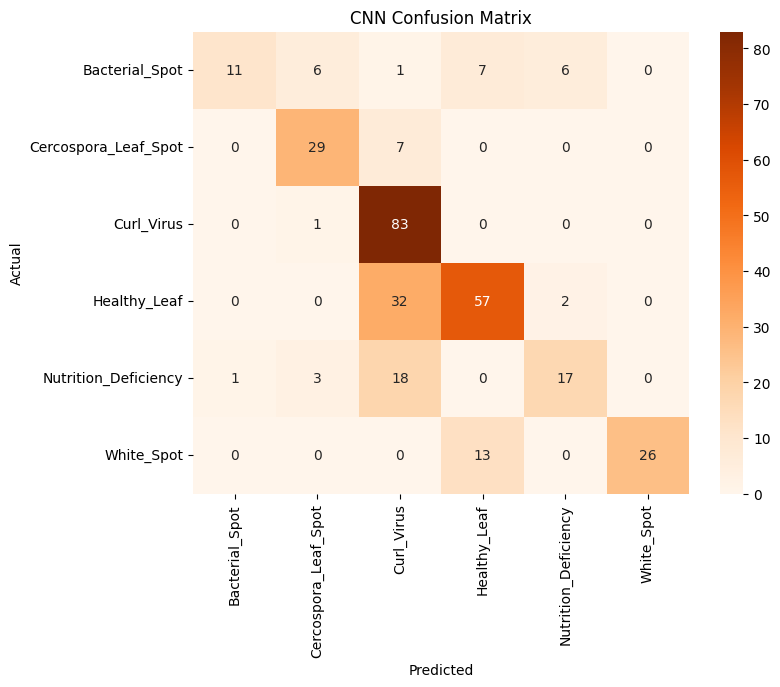

CNN Accuracy: 69.69%


In [ ]:
val_data.reset()
y_pred_probs_cnn = cnn_model.predict(val_data)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
y_true = val_data.classes

print("=== CNN Classification Report ===")
print(classification_report(y_true, y_pred_cnn, target_names=class_labels))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

cnn_accuracy = (y_pred_cnn == y_true).mean() * 100
print(f"CNN Accuracy: {cnn_accuracy:.2f}%")

# **ViT Model + Processor Load**

In [ ]:
!pip install --upgrade sympy

In [ ]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

processor = ViTImageProcessor.from_pretrained('/content/drive/MyDrive/ChiliDoc_Models/chilidoc_vit_model')
vit_model = ViTForImageClassification.from_pretrained('/content/drive/MyDrive/ChiliDoc_Models/chilidoc_vit_model')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)
vit_model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

# **Validation Dataset for ViT**

In [ ]:
class ChiliDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.root_dir = root_dir
        self.processor = processor
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.image_paths = []
        self.labels = []
        for idx, cls in enumerate(self.classes):
            cls_folder = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_folder):
                self.image_paths.append(os.path.join(cls_folder, img_name))
                self.labels.append(idx)
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        pixel_values = self.processor(image, return_tensors="pt")['pixel_values'].squeeze(0)
        return pixel_values, label

full_dataset = ChiliDataset(dataset_path, processor)

torch.manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
_, vit_val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

vit_val_loader = DataLoader(vit_val_dataset, batch_size=16, shuffle=False)

# **ViT Predictions + Confusion Matrix**

=== ViT Classification Report ===
                      precision    recall  f1-score   support

      Bacterial_Spot       0.97      0.97      0.97        34
Cercospora_Leaf_Spot       0.97      0.97      0.97        37
          Curl_Virus       1.00      1.00      1.00        93
        Healthy_Leaf       1.00      1.00      1.00        94
Nutrition_Deficiency       1.00      1.00      1.00        30
          White_Spot       1.00      1.00      1.00        34

            accuracy                           0.99       322
           macro avg       0.99      0.99      0.99       322
        weighted avg       0.99      0.99      0.99       322



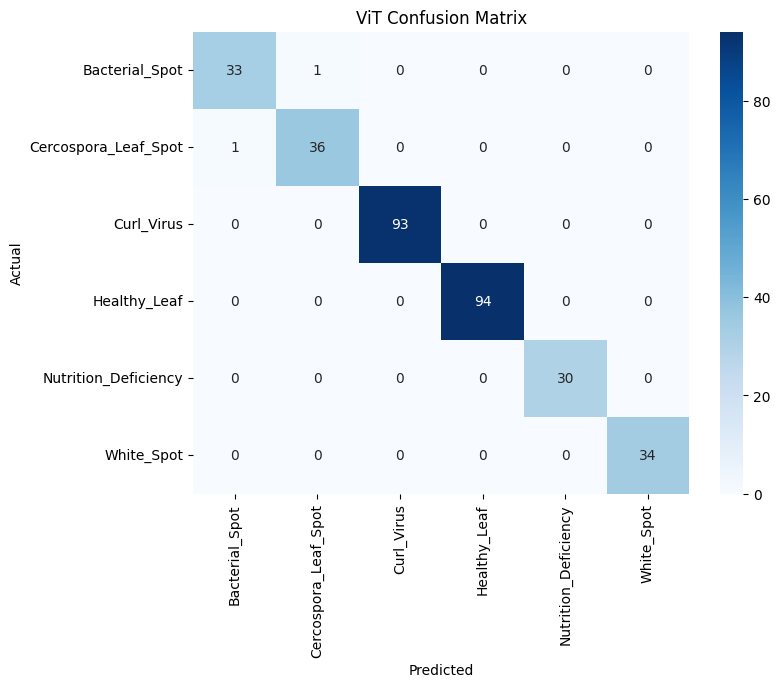

ViT Accuracy: 99.38%


In [ ]:
all_preds_vit = []
all_labels_vit = []

with torch.no_grad():
    for pixel_values, labels in vit_val_loader:
        pixel_values, labels = pixel_values.to(device), labels.to(device)
        outputs = vit_model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds_vit.extend(preds.cpu().numpy())
        all_labels_vit.extend(labels.cpu().numpy())

print("=== ViT Classification Report ===")
print(classification_report(all_labels_vit, all_preds_vit, target_names=full_dataset.classes))

cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)
plt.figure(figsize=(8,6))
sns.heatmap(cm_vit, annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ViT Confusion Matrix')
plt.show()

vit_accuracy = (np.array(all_preds_vit) == np.array(all_labels_vit)).mean() * 100
print(f"ViT Accuracy: {vit_accuracy:.2f}%")

# **Final Comparison Bar Chart**

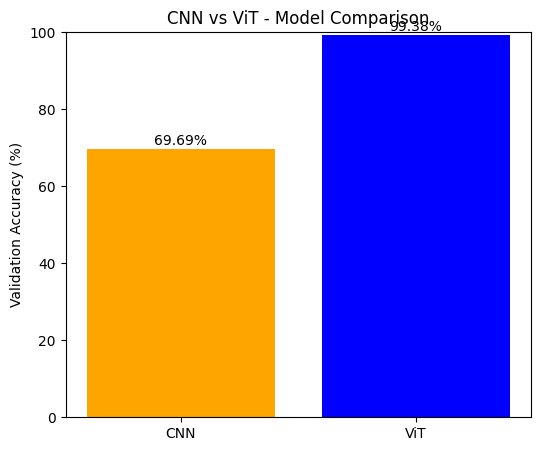

In [ ]:
models = ['CNN', 'ViT']
accuracies = [cnn_accuracy, vit_accuracy]

plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies, color=['orange', 'blue'])
plt.ylabel('Validation Accuracy (%)')
plt.title('CNN vs ViT - Model Comparison')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1, f'{acc:.2f}%', ha='center')

plt.show()